In [2]:
pip install sentence-transformers faiss-cpu numpy

   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---

In [5]:
!pip install datasets nltk spacy scikit-learn gensim matplotlib pandas
!python -m spacy download en_core_web_sm

   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 527.0/527.0 kB 11.2 MB/s  0:00:00
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   ---------------------------------------  14.2/14.2 MB 70.6 MB/s eta 0:00:01
   ---------------------------------------- 14.2/14.2 MB 50.1 MB/s  0:00:00
   ---------------------------------------- 0.0/650.8 kB ? eta -:--:--
   ---------------------------------------- 650.8/650.8 kB 21.7 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 27.7 MB/s  0:00:00
   ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
   ---------------------------------------- 6.2/6.2 MB 48.9 MB/s  0:00:00
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------- ----------------------------- 6.6/24.4 MB 36.5 MB/s eta 0:00:01
   ----------------------- ----------------

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading dataset...
Number of documents loaded: 2000
Preprocessing texts...
Sample processed document:
['rent', 'curious', 'yellow', 'video', 'store', 'controversy', 'surround', 'first', 'release', 'also', 'hear', 'first', 'seize', 'u', 'custom', 'ever', 'try', 'enter', 'country', 'therefore']

Vocabulary size: 18496
Sample vocabulary words: ['I', 'aaaahhhhhhh', 'aaaarrgh', 'aaargh', 'aahhh', 'aame', 'aankhen', 'aapke', 'aargh', 'aaron', 'ab', 'abandon', 'abandonment', 'abbas', 'abbott', 'abc', 'abduct', 'abducted', 'abductor', 'abdul']

Creating Bag of Words and TF-IDF vectors...
Bag of Words shape: (2000, 18473)
TF-IDF shape: (2000, 18473)

Training Word2Vec model...
Word2Vec vocabulary size: 10521

Words similar to 'movie':
[('really', 0.9927144646644592), ('see', 0.9914999604225159), ('ever', 0.9861303567886353), ('watch', 0.9844759106636047), ('good', 0.982549250125885)]

Generating sentence embeddings...
Sentence embeddings shape: (2000, 100)

Top Similar Comments:

Rank 1
Index: 

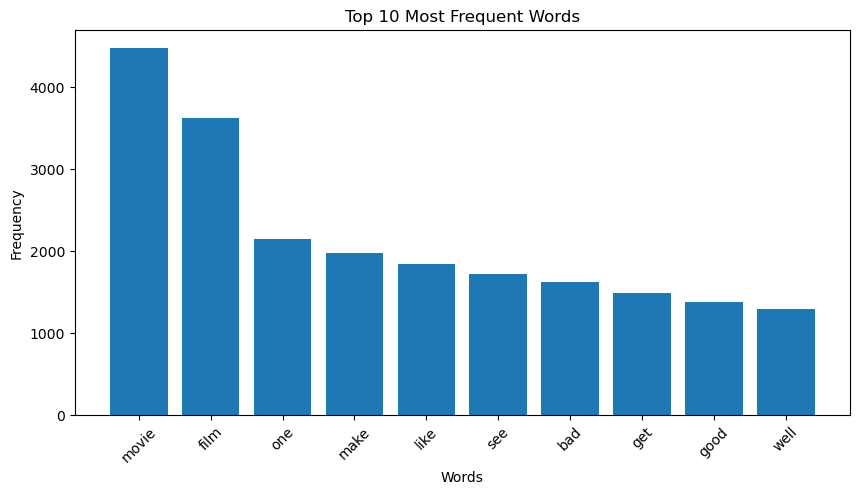

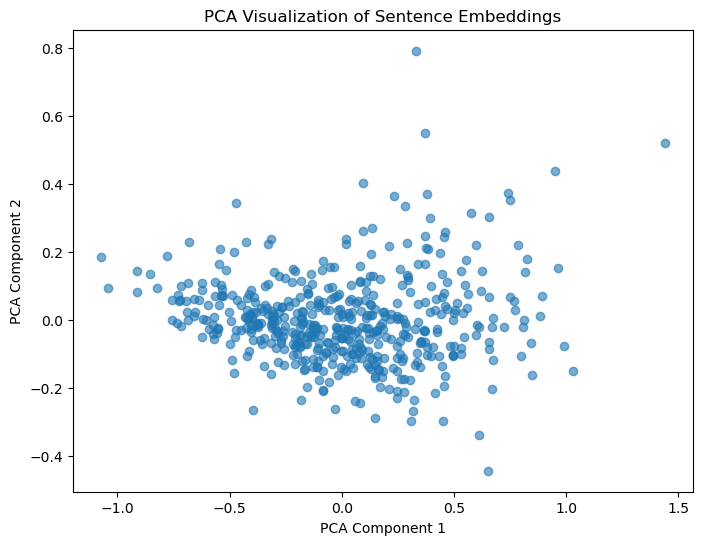

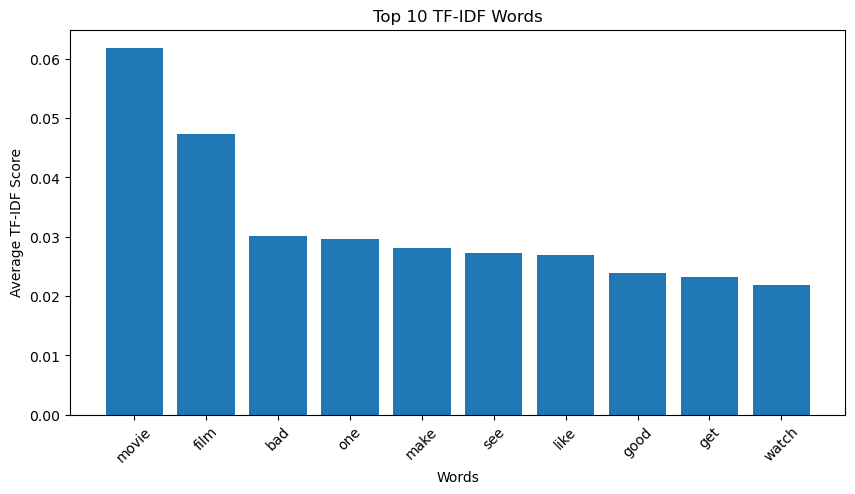


===== FINAL SUMMARY =====
1. Text cleaning completed
2. Tokenization completed
3. Stopword removal completed
4. Lemmatization completed
5. Vocabulary created
6. Bag of Words vectors generated
7. TF-IDF vectors generated
8. Word2Vec embeddings trained
9. Sentence embeddings generated
10. Similarity search implemented
11. Insights and visualizations generated

Pipeline successfully completed.


In [8]:
# ================================
# Assignment 4: Semantic Search Ready NLP Pipeline
# ================================

# 1. IMPORT LIBRARIES
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import spacy

from datasets import load_dataset

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

from gensim.models import Word2Vec

# 2. DOWNLOAD REQUIRED NLTK DATA
nltk.download("punkt")
nltk.download("stopwords")

# 3. LOAD SPACY MODEL
nlp = spacy.load("en_core_web_sm")

# 4. LOAD HUGGING FACE DATASET
print("Loading dataset...")
dataset = load_dataset("imdb")

# Use a smaller subset first for faster execution
train_texts = dataset["train"]["text"][:2000]

print("Number of documents loaded:", len(train_texts))


# ================================
# STEP 1: TEXT CLEANING
# ================================
def clean_text(text):
    text = text.lower()                              # lowercase
    text = re.sub(r"<.*?>", " ", text)              # remove html tags
    text = re.sub(r"[^a-z\s]", " ", text)           # keep only letters and spaces
    text = re.sub(r"\s+", " ", text).strip()        # remove extra spaces
    return text


# ================================
# STEP 2: TOKENIZATION
# STEP 3: STOPWORD REMOVAL
# STEP 4: LEMMATIZATION
# ================================
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    # clean
    text = clean_text(text)
    
    # tokenize
    tokens = word_tokenize(text)
    
    # remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # lemmatization using spacy
    doc = nlp(" ".join(tokens))
    lemmas = [token.lemma_ for token in doc if token.lemma_.strip()]
    
    return lemmas


print("Preprocessing texts...")
processed_docs = [preprocess_text(text) for text in train_texts]

# Convert token lists back to text for vectorizers
processed_texts = [" ".join(doc) for doc in processed_docs]

print("Sample processed document:")
print(processed_docs[0][:20])


# ================================
# STEP 5: VOCABULARY CREATION
# ================================
vocab = sorted(set(word for doc in processed_docs for word in doc))
print("\nVocabulary size:", len(vocab))
print("Sample vocabulary words:", vocab[:20])


# ================================
# STEP 6: BAG OF WORDS / TF-IDF
# ================================
print("\nCreating Bag of Words and TF-IDF vectors...")

# Bag of Words
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(processed_texts)

# TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(processed_texts)

print("Bag of Words shape:", X_bow.shape)
print("TF-IDF shape:", X_tfidf.shape)


# ================================
# STEP 7: WORD EMBEDDINGS (WORD2VEC)
# ================================
print("\nTraining Word2Vec model...")

w2v_model = Word2Vec(
    sentences=processed_docs,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

print("Word2Vec vocabulary size:", len(w2v_model.wv.index_to_key))

# Example: check similar words
sample_word = "movie"
if sample_word in w2v_model.wv:
    print(f"\nWords similar to '{sample_word}':")
    print(w2v_model.wv.most_similar(sample_word, topn=5))
else:
    print(f"\n'{sample_word}' not found in Word2Vec vocabulary.")


# ================================
# STEP 8: SENTENCE EMBEDDINGS
# ================================
def sentence_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

print("\nGenerating sentence embeddings...")
sentence_embeddings = np.array([sentence_vector(doc, w2v_model) for doc in processed_docs])

print("Sentence embeddings shape:", sentence_embeddings.shape)


# ================================
# STEP 9: SIMILARITY SEARCH
# ================================
def search_similar_comments(query, top_k=5):
    query_tokens = preprocess_text(query)
    query_embedding = sentence_vector(query_tokens, w2v_model).reshape(1, -1)
    
    similarities = cosine_similarity(query_embedding, sentence_embeddings)[0]
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = []
    for idx in top_indices:
        results.append({
            "index": idx,
            "similarity_score": float(similarities[idx]),
            "original_text": train_texts[idx][:500]
        })
    return results


# Example query
query = "This movie was emotional and beautifully acted"
results = search_similar_comments(query, top_k=3)

print("\nTop Similar Comments:")
for i, result in enumerate(results, 1):
    print(f"\nRank {i}")
    print("Index:", result["index"])
    print("Similarity Score:", round(result["similarity_score"], 4))
    print("Text:", result["original_text"])


# ================================
# STEP 10: INSIGHTS & VISUALIZATION
# ================================

# A. Most frequent words
all_words = [word for doc in processed_docs for word in doc]
word_counts = Counter(all_words).most_common(10)

words = [item[0] for item in word_counts]
counts = [item[1] for item in word_counts]

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()


# B. PCA visualization of sentence embeddings
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(sentence_embeddings[:500])

plt.figure(figsize=(8, 6))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], alpha=0.6)
plt.title("PCA Visualization of Sentence Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


# C. Top TF-IDF words across corpus
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = np.asarray(X_tfidf.mean(axis=0)).ravel()

top_tfidf_indices = tfidf_scores.argsort()[-10:][::-1]
top_tfidf_words = [tfidf_feature_names[i] for i in top_tfidf_indices]
top_tfidf_values = [tfidf_scores[i] for i in top_tfidf_indices]

plt.figure(figsize=(10, 5))
plt.bar(top_tfidf_words, top_tfidf_values)
plt.title("Top 10 TF-IDF Words")
plt.xlabel("Words")
plt.ylabel("Average TF-IDF Score")
plt.xticks(rotation=45)
plt.show()


# ================================
# FINAL SUMMARY OUTPUT
# ================================
print("\n===== FINAL SUMMARY =====")
print("1. Text cleaning completed")
print("2. Tokenization completed")
print("3. Stopword removal completed")
print("4. Lemmatization completed")
print("5. Vocabulary created")
print("6. Bag of Words vectors generated")
print("7. TF-IDF vectors generated")
print("8. Word2Vec embeddings trained")
print("9. Sentence embeddings generated")
print("10. Similarity search implemented")
print("11. Insights and visualizations generated")
print("\nPipeline successfully completed.")

In [9]:
query = "This movie was very emotional"

In [12]:
query = "This movie was boring and slow"
results = search_similar_comments(query, top_k=3)

for i, result in enumerate(results, 1):
    print(f"\n🔹 Rank {i}")
    print("Similarity Score:", round(result["similarity_score"], 4))
    print("Review:", result["original_text"][:300])


🔹 Rank 1
Similarity Score: 0.9998
Review: This movie is by far the worst movie ever made. If you have to create a film costarring the guy who plays Lars in heavyweights than don't make the damn film. I have to say that I could watch Leprechaun in Space 6 times before I could watch the trailer for this POS of a movie. Adam sandler should be 

🔹 Rank 2
Similarity Score: 0.9998
Review: This movie is about as underrated as Police Acadmey Mission to Moscow. This movie is never funny. It's maybe the worst comedy spoof ever made. Very boring,and dumb beyond belief. For those people that think this movie is underrated god help you. I give this movie * out of ****<br /><br />

🔹 Rank 3
Similarity Score: 0.9998
Review: Really, I can't believe that I spent $5 on this movie. I am a huge zombie fanatic and thought the movie couldn't be that bad. It had zombies in it right? Was I wrong! To be honest the movie had it's moments...I thought it was cool when the guy got his head ripped off but that was